In [9]:
import pandas as pd
# import spacy
# from sklearn.metrics.pairwise import cosine_similarity

from gensim.models import KeyedVectors

# Load pre-trained word vectors (Google News Word2Vec format)
# This will download ~1.5GB on first run
import gensim.downloader as api
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity


In [ ]:
model1 = api.load("word2vec-google-news-300")
# Load model
model2 = SentenceTransformer("all-MiniLM-L6-v2")

In [29]:
df = pd.read_csv("../exp_files/pilot_n.csv")

# Differences between Word2Vec and BERT embeddings for similarity
Aspect	Word2Vec Google News (300d)	SentenceTransformer all-MiniLM-L6-v2 (384d)
Type of embedding	Word-level embedding	Sentence / phrase embedding (can also be single words)
Training data	Google News corpus (~100 billion tokens)	Large-scale datasets with sentences and semantic labels (e.g. NLI, STS)
Vector size	300 dimensions	384 dimensions
Context	Static embeddings: Each word has one vector regardless of context	Contextual embeddings (fine-tuned for sentence similarity)
Usage	Good for general word similarity and analogy	Excellent for sentence, phrase, and word similarity — captures semantics better
Similarity measure	Cosine similarity on static vectors	Cosine similarity on context-aware vectors
Out-of-vocabulary handling	Words not in vocab get no vector	Can embed any text string, including OOV words
Performance	Fast, lightweight, easy to use	Slightly heavier model, but more powerful and versatile
Meaning captured	Word co-occurrence patterns	Semantic meaning in context, better for polysemy and phrase meaning

In simpler terms:
Word2Vec gives you a single fixed vector per word, learned from word co-occurrence statistics in a huge news corpus. It doesn’t consider context — the vector for “bank” is the same whether it’s a river bank or a financial bank.

SentenceTransformer embeddings are generated by a transformer model trained on tasks that require understanding sentence meaning. Even a single word embedding reflects some context and semantic nuance. It works better for phrases, sentences, or words with multiple meanings.

When to use which?
Task	Recommended model
Simple word similarity or analogies	Word2Vec Google News
Sentence or phrase similarity	SentenceTransformer (MiniLM or others)
Handling ambiguous or out-of-vocab words	SentenceTransformer
Downstream NLP tasks requiring semantic understanding

# Get similarity with word-2-vec

In [30]:


def get_similarity(w1, w2):
    if w1 in model1 and w2 in model1:
        return model1.similarity(w1, w2)
    else:
        return None  # or 0, or np.nan
df["W2VSimilarity"] = df.apply(lambda row: get_similarity(row["Word1"], row["Word2"]), axis=1)

df.head()

,Unnamed: 0,Word1,Word2,FeatureCombo1,FeatureCombo2,FeatureMatch,W2VSimilarity
0,95,envy,kindness,abstract-negative,abstract-positive,ConceptualMatchingOnly,0.186578
1,30,despair,love,abstract-negative,abstract-positive,ConceptualMatchingOnly,0.372775
2,158,hug,stench,concrete-positive,concrete-negative,ConceptualMatchingOnly,0.126435
3,115,laughter,rust,concrete-positive,concrete-negative,ConceptualMatchingOnly,0.064257
4,69,resentment,inspiration,abstract-negative,abstract-positive,ConceptualMatchingOnly,0.151568


<Axes: ylabel='Density'>

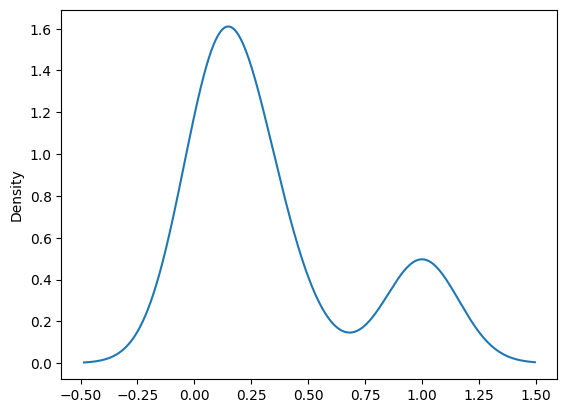

In [31]:
df["W2VSimilarity"].plot.kde()

In [32]:
df["W2VSimilarity"].isnull().values.any()

False

In [33]:
# Assuming df is your DataFrame
nan_combos = df[df["W2VSimilarity"].isna()][["Word1", "Word2"]]
print(nan_combos)

Empty DataFrame
Columns: [Word1, Word2]
Index: []


# Try with BERT

In [34]:


# Compute similarities
def get_similarity(w1, w2):
    v1 = model2.encode(w1)
    v2 = model2.encode(w2)
    return cosine_similarity([v1], [v2])[0][0]

df["CosineSimilarity"] = df.apply(lambda row: get_similarity(row["Word1"], row["Word2"]), axis=1)

df.head()

,Unnamed: 0,Word1,Word2,FeatureCombo1,FeatureCombo2,FeatureMatch,W2VSimilarity,CosineSimilarity
0,95,envy,kindness,abstract-negative,abstract-positive,ConceptualMatchingOnly,0.186578,0.412939
1,30,despair,love,abstract-negative,abstract-positive,ConceptualMatchingOnly,0.372775,0.242015
2,158,hug,stench,concrete-positive,concrete-negative,ConceptualMatchingOnly,0.126435,0.242786
3,115,laughter,rust,concrete-positive,concrete-negative,ConceptualMatchingOnly,0.064257,0.284964
4,69,resentment,inspiration,abstract-negative,abstract-positive,ConceptualMatchingOnly,0.151568,0.334424


In [35]:
df.to_csv("../exp_files/pilot_n_similarity.csv")